In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("../data/online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [6]:
print("Duplicate rows:", df.duplicated().sum())

print("Missing values:")
print(df.isnull().sum())

Duplicate rows: 5268
Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove rows without essential information
df_clean = df_clean.dropna(
    subset=["CustomerID", "Description", "InvoiceDate"]
)

# Convert date column
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"],
    errors="coerce"
)

# Remove invalid dates
df_clean = df_clean.dropna(subset=["InvoiceDate"])

# Remove cancelled transactions
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep positive sales quantities and prices
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

# Create revenue column
df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

df_clean.head()

Original shape: (541909, 8)
Cleaned shape: (166363, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34


In [8]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year

df_clean["Month"] = df_clean["InvoiceDate"].dt.month

df_clean["MonthName"] = (
    df_clean["InvoiceDate"].dt.strftime("%b")
)

df_clean["Day"] = df_clean["InvoiceDate"].dt.day

df_clean["Weekday"] = (
    df_clean["InvoiceDate"].dt.day_name()
)

df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Day,Weekday,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,1,Jan,12,Tuesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,1,Jan,12,Tuesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,1,Jan,12,Tuesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,1,Jan,12,Tuesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,1,Jan,12,Tuesday,8


In [9]:
total_revenue = df_clean["Revenue"].sum()

total_orders = df_clean["InvoiceNo"].nunique()

total_customers = df_clean["CustomerID"].nunique()

total_products = df_clean["StockCode"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Revenue: 3865463.08
Total Orders: 7961
Total Customers: 2997
Total Products: 3507


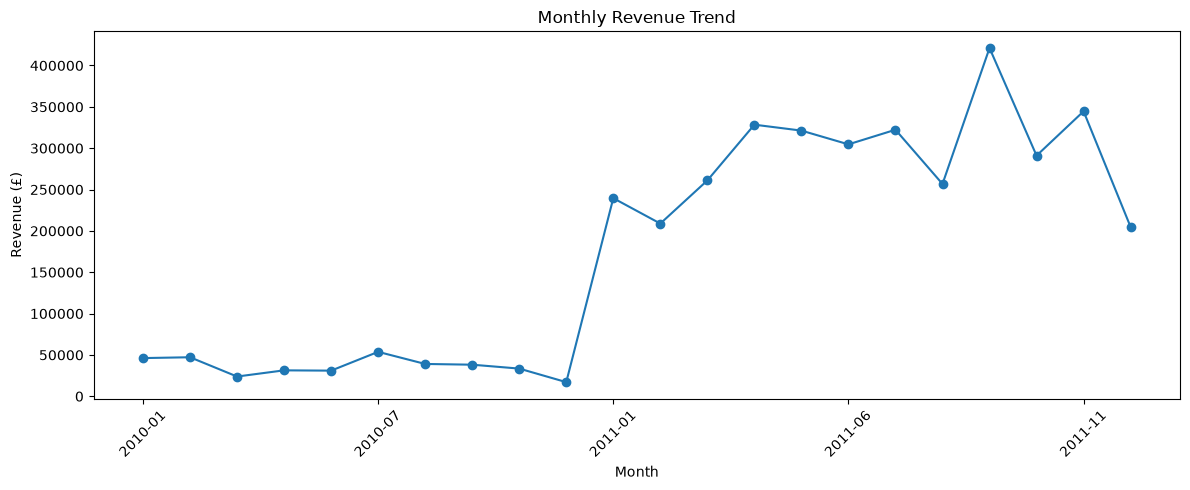

In [10]:
monthly_sales = (
    df_clean.groupby(
        df_clean["InvoiceDate"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

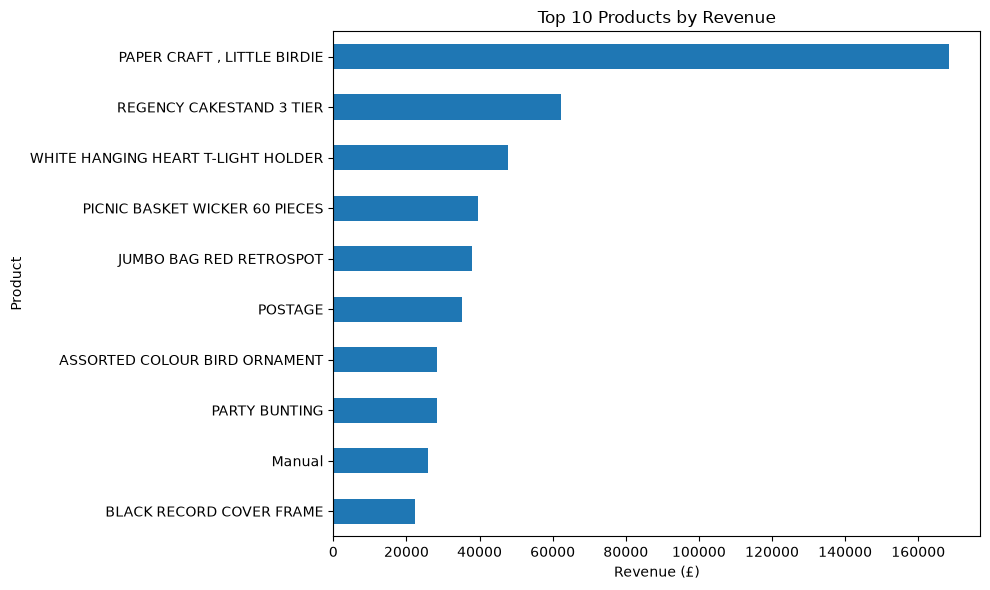

In [11]:
top_products = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

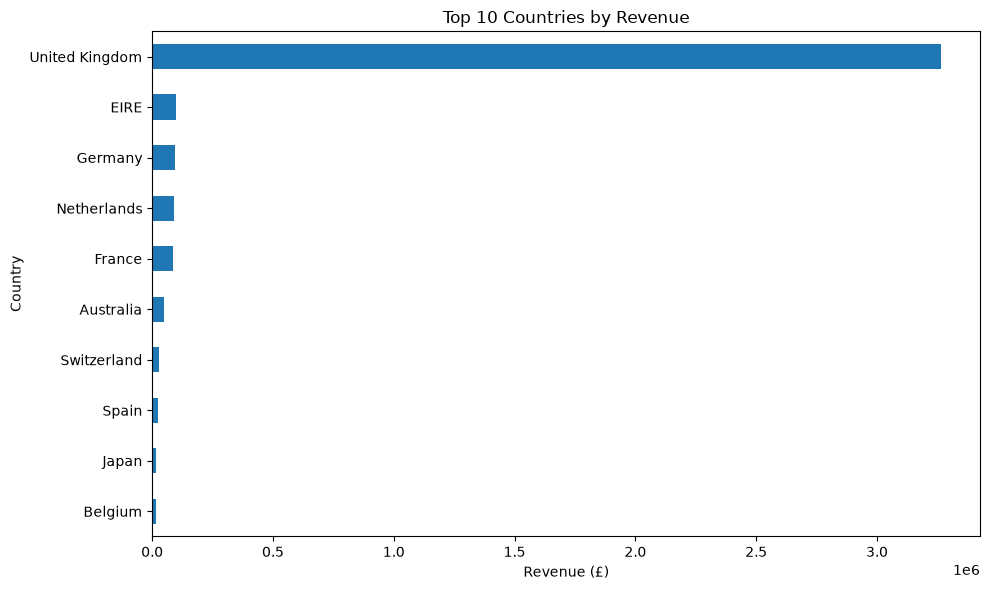

In [12]:
country_sales = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [13]:
daily_sales = (
    df_clean.groupby(
        df_clean["InvoiceDate"].dt.date
    )["Revenue"]
    .sum()
    .reset_index()
)

daily_sales.columns = ["Date", "Revenue"]

daily_sales["Date"] = pd.to_datetime(
    daily_sales["Date"]
)

daily_sales["Day"] = daily_sales["Date"].dt.day
daily_sales["Month"] = daily_sales["Date"].dt.month
daily_sales["Year"] = daily_sales["Date"].dt.year
daily_sales["Weekday"] = daily_sales["Date"].dt.dayofweek

daily_sales.head()

,Date,Revenue,Day,Month,Year,Weekday
0,2010-01-12,46192.49,12,1,2010,1
1,2010-02-12,47197.57,12,2,2010,4
2,2010-03-12,23876.63,12,3,2010,4
3,2010-05-12,31361.28,12,5,2010,2
4,2010-06-12,31009.33,12,6,2010,5


In [14]:
features = ["Day", "Month", "Year", "Weekday"]

X = daily_sales[features]
y = daily_sales["Revenue"]

# Keep the final 20% of dates for testing
split_index = int(len(daily_sales) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Linear Regression MAE:",
      mean_absolute_error(y_test, lr_predictions))

print("Decision Tree MAE:",
      mean_absolute_error(y_test, dt_predictions))

print("Linear Regression R2:",
      r2_score(y_test, lr_predictions))

print("Decision Tree R2:",
      r2_score(y_test, dt_predictions))

Linear Regression MAE: 13475.060530193045
Decision Tree MAE: 16311.522367216114
Linear Regression R2: 0.00020297981843353519
Decision Tree R2: -2.31780484194093


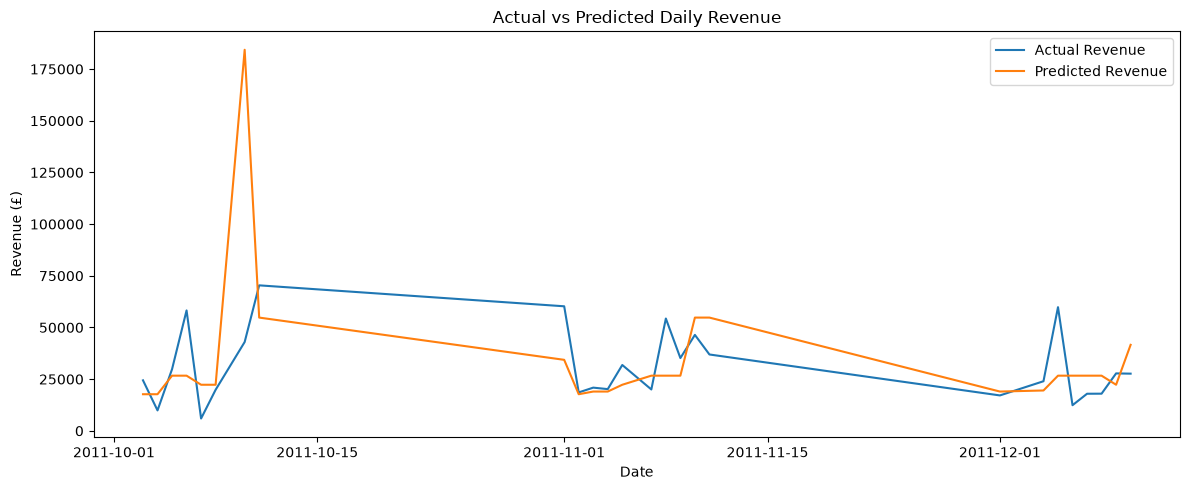

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["Date"].iloc[split_index:],
    y_test,
    label="Actual Revenue"
)

plt.plot(
    daily_sales["Date"].iloc[split_index:],
    dt_predictions,
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (£)")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
snapshot_date = (
    df_clean["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate",
                 lambda x: (snapshot_date - x.max()).days),

        Frequency=("InvoiceNo", "nunique"),

        Monetary=("Revenue", "sum")
    )
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,96,5,2540.29
12348.0,221,1,367.00
12350.0,312,1,334.40
12352.0,275,3,1296.38
12355.0,97,1,459.40


In [17]:
rfm_log = np.log1p(rfm)

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,96,5,2540.29,1
12348.0,221,1,367.00,0
12350.0,312,1,334.40,0
12352.0,275,3,1296.38,1
12355.0,97,1,459.40,0


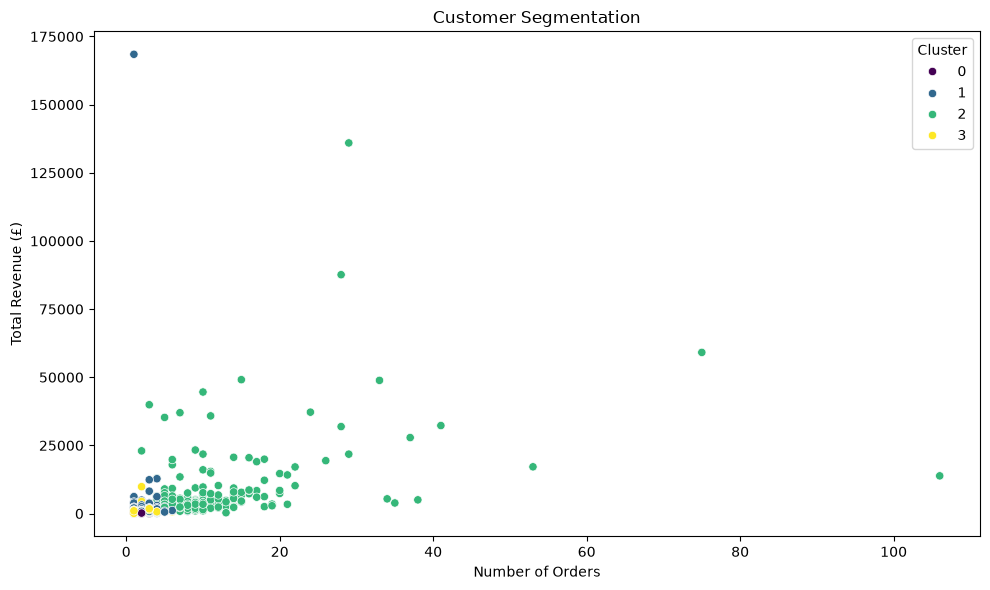

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segmentation")
plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue (£)")

plt.tight_layout()
plt.show()

In [19]:
df_clean.to_csv(
    "../outputs/cleaned_retail_data.csv",
    index=False
)

rfm.to_csv(
    "../outputs/customer_segments.csv"
)

daily_sales.to_csv(
    "../outputs/daily_sales.csv",
    index=False
)

In [20]:
import os

os.makedirs("../outputs", exist_ok=True)

# Cleaned transaction data
df_clean.to_csv(
    "../outputs/cleaned_retail_data.csv",
    index=False
)

# Customer segmentation data
rfm.to_csv(
    "../outputs/customer_segments.csv"
)

# Daily revenue data
daily_sales.to_csv(
    "../outputs/daily_sales.csv",
    index=False
)

print("Files exported successfully!")

Files exported successfully!


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Make sure daily_sales has Date and Revenue columns
daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])
daily_sales = daily_sales.sort_values("Date")

# Use the first 80% of dates for training
split_index = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split_index]
test = daily_sales.iloc[split_index:]

X_train = train[["Date"]].copy()
X_test = test[["Date"]].copy()

# Convert dates to numeric values for the model
X_train["Date"] = X_train["Date"].map(pd.Timestamp.toordinal)
X_test["Date"] = X_test["Date"].map(pd.Timestamp.toordinal)

y_train = train["Revenue"]
y_test = test["Revenue"]

# Train model and predict
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Create prediction dataset
revenue_predictions = pd.DataFrame({
    "Date": test["Date"].values,
    "ActualRevenue": y_test.values,
    "PredictedRevenue": predictions
})

# Save the file
revenue_predictions.to_csv(
    "../outputs/revenue_predictions.csv",
    index=False
)

print("Prediction file created successfully!")

Prediction file created successfully!
